# Lab 4
## Abdulaziz Saqer BinRuqush - 2230007229

### Environment Setup
This cell installs any missing packages. It is safe in both local Jupyter and Google Colab.


In [1]:
import importlib
import subprocess
import sys
from pathlib import Path

local_site = Path('.pydeps')
local_site.mkdir(exist_ok=True)
local_site_str = str(local_site.resolve())
if local_site_str not in sys.path:
    # Keep base environment first to avoid ABI mismatch for preinstalled compiled packages.
    sys.path.append(local_site_str)


def ensure_module(module_name, install_specs):
    try:
        module = importlib.import_module(module_name)
        print(f'{module_name} already available.')
        return module
    except Exception as exc:
        print(f'Installing {module_name} ({exc.__class__.__name__}).')

    cmd = [
        sys.executable,
        '-m',
        'pip',
        'install',
        '--upgrade',
        '--target',
        local_site_str,
        *install_specs,
    ]
    subprocess.check_call(cmd)
    importlib.invalidate_caches()
    return importlib.import_module(module_name)


# Ensure core scientific stack from base env
importlib.import_module('numpy')
importlib.import_module('matplotlib')
importlib.import_module('PIL')

# Install only packages missing from base env into local folder with NumPy<2 compatibility.
ensure_module('cv2', ['opencv-python-headless==4.10.0.84', 'numpy<2'])
ensure_module('skimage', ['scikit-image==0.22.0', 'numpy<2'])

print('Dependency check complete.')


cv2 already available.
skimage already available.
Dependency check complete.


### Path and Utility Helpers
These helpers make the notebook run on both local Jupyter and Google Colab.


In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data, exposure


def is_colab():
    return Path('/content').exists()


def find_images_dir():
    candidates = []
    if is_colab():
        candidates.extend([
            Path('/content/Images'),
            Path('/content/Labs/Images')
        ])
    cwd = Path.cwd()
    candidates.extend([
        cwd / 'Images',
        cwd.parent / 'Images'
    ])
    for p in candidates:
        if p.exists():
            return p
    return None


IMAGES_DIR = find_images_dir()
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
print(f'Colab runtime: {is_colab()}')
print(f'Images dir: {IMAGES_DIR}')
print(f'Output dir: {OUTPUT_DIR.resolve()}')


def show_images(images, titles, cmap=None, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, len(images), i)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap if cmap else 'gray')
        else:
            plt.imshow(img)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def to_rgb(image_bgr):
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def load_color_image_fallback():
    if IMAGES_DIR is not None:
        for name in ['Parrot.png', 'parrot.png', 'input.jpg', 'input.png', 'lena_grayscale_image.jpg']:
            p = IMAGES_DIR / name
            if p.exists():
                img = cv2.imread(str(p), cv2.IMREAD_COLOR)
                if img is not None:
                    print(f'Loaded local image: {p}')
                    return img
    print('Using skimage.data.astronaut() as fallback color image.')
    astro_rgb = data.astronaut()
    return cv2.cvtColor(astro_rgb, cv2.COLOR_RGB2BGR)


def load_gray_image_fallback():
    if IMAGES_DIR is not None:
        for name in ['cameraman.jpg', 'lena_grayscale_image.jpg', 'input.jpg', 'input.png']:
            p = IMAGES_DIR / name
            if p.exists():
                img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    print(f'Loaded local grayscale image: {p}')
                    return img
    print('Using skimage.data.camera() as fallback grayscale image.')
    cam = data.camera()
    return cam.astype(np.uint8)


Colab runtime: False
Images dir: C:\Users\aziz\OneDrive\Desktop\Level 8\Image Processing\Labs\Images
Output dir: C:\Users\aziz\OneDrive\Desktop\Level 8\Image Processing\Labs\outputs


## Procedural Steps

### Task 1, Step 1: Fixed Thresholding

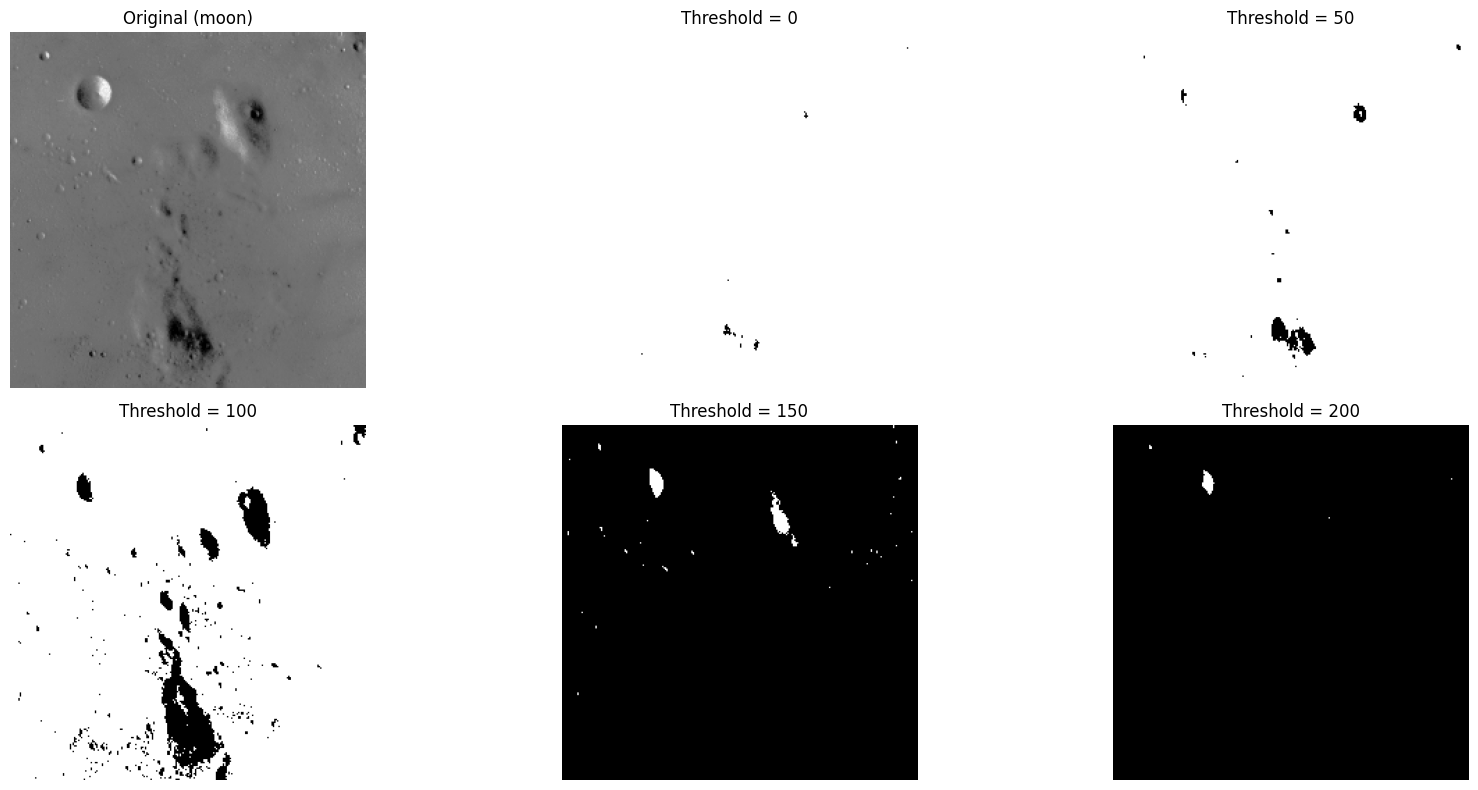

In [3]:
moon_img = data.moon().astype(np.uint8)
threshold_values = [0, 50, 100, 150, 200]

results = [moon_img]
titles = ['Original (moon)']

for t in threshold_values:
    _, thresh = cv2.threshold(moon_img, t, 255, cv2.THRESH_BINARY)
    results.append(thresh)
    titles.append(f'Threshold = {t}')

# Display in two rows for readability
plt.figure(figsize=(18, 8))
for i, (img, title) in enumerate(zip(results, titles), start=1):
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()


### Task 2, Steps 1-4: Histogram Processing and Contrast Stretching (2nd-98th percentile)

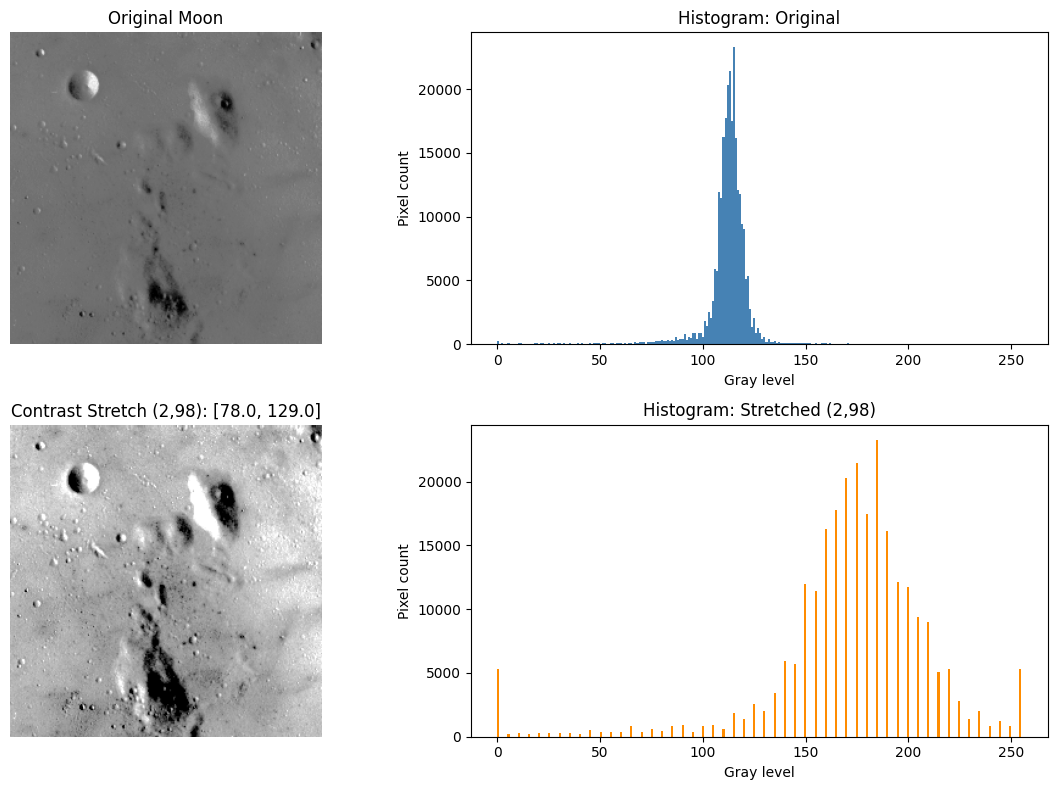

In [4]:
p2, p98 = np.percentile(moon_img, (2, 98))
moon_rescale_2_98 = exposure.rescale_intensity(moon_img, in_range=(p2, p98))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(moon_img, cmap='gray')
axes[0, 0].set_title('Original Moon')
axes[0, 0].axis('off')

axes[0, 1].hist(moon_img.ravel(), bins=256, range=(0, 255), color='steelblue')
axes[0, 1].set_title('Histogram: Original')
axes[0, 1].set_xlabel('Gray level')
axes[0, 1].set_ylabel('Pixel count')

axes[1, 0].imshow(moon_rescale_2_98, cmap='gray')
axes[1, 0].set_title(f'Contrast Stretch (2,98): [{p2:.1f}, {p98:.1f}]')
axes[1, 0].axis('off')

axes[1, 1].hist(moon_rescale_2_98.ravel(), bins=256, range=(0, 255), color='darkorange')
axes[1, 1].set_title('Histogram: Stretched (2,98)')
axes[1, 1].set_xlabel('Gray level')
axes[1, 1].set_ylabel('Pixel count')

plt.tight_layout()
plt.show()


## Assessment Tasks

### Task 1: Contrast Stretching with 3rd and 80th Percentiles

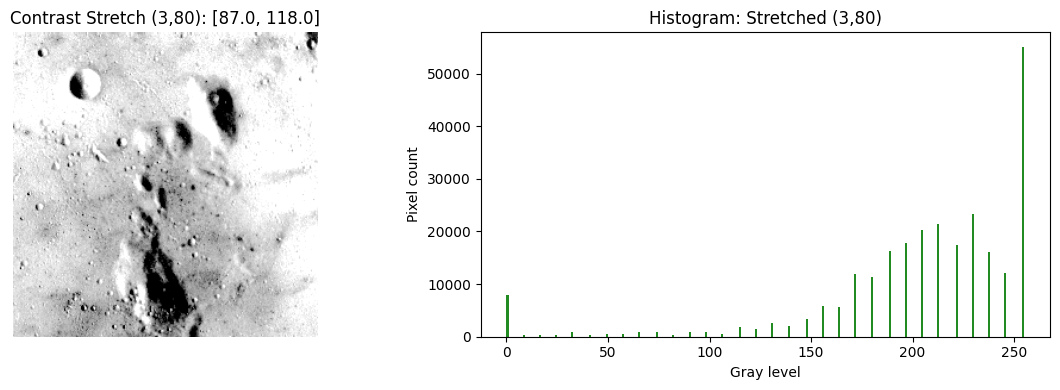

In [5]:
p3, p80 = np.percentile(moon_img, (3, 80))
moon_rescale_3_80 = exposure.rescale_intensity(moon_img, in_range=(p3, p80))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(moon_rescale_3_80, cmap='gray')
axes[0].set_title(f'Contrast Stretch (3,80): [{p3:.1f}, {p80:.1f}]')
axes[0].axis('off')

axes[1].hist(moon_rescale_3_80.ravel(), bins=256, range=(0, 255), color='forestgreen')
axes[1].set_title('Histogram: Stretched (3,80)')
axes[1].set_xlabel('Gray level')
axes[1].set_ylabel('Pixel count')

plt.tight_layout()
plt.show()


### Task 2: Histogram Equalization on Moon Image

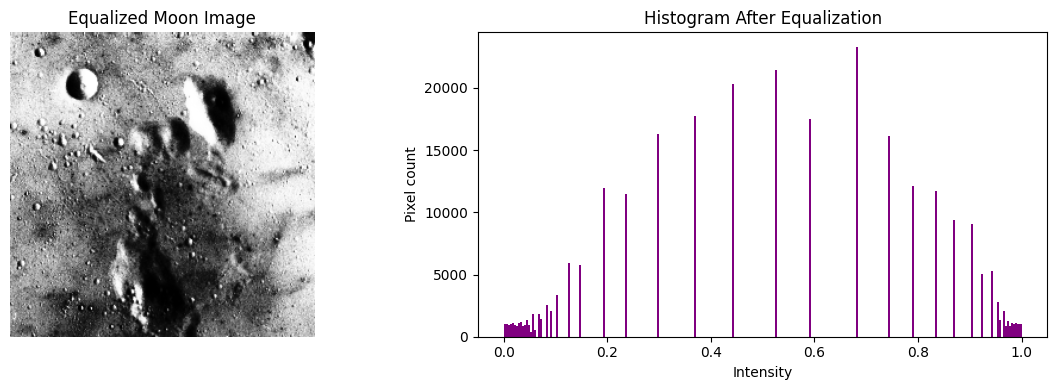

In [6]:
moon_eq = exposure.equalize_hist(moon_img)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(moon_eq, cmap='gray')
axes[0].set_title('Equalized Moon Image')
axes[0].axis('off')

axes[1].hist(moon_eq.ravel(), bins=256, range=(0, 1), color='purple')
axes[1].set_title('Histogram After Equalization')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Pixel count')

plt.tight_layout()
plt.show()


### Task 3: Histogram Matching (Chelsea -> Rocket Reference)

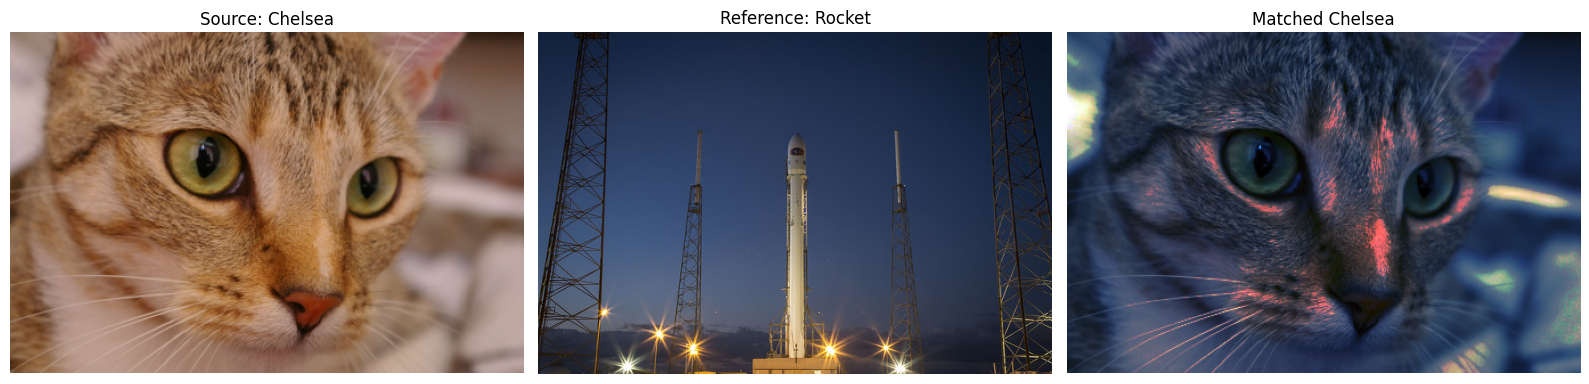

In [7]:
rocket = data.rocket()
chelsea = data.chelsea()

try:
    matched = exposure.match_histograms(chelsea, rocket, channel_axis=-1)
except TypeError:
    # Compatibility with older versions of scikit-image
    matched = exposure.match_histograms(chelsea, rocket, multichannel=True)

matched = np.clip(matched, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(chelsea)
axes[0].set_title('Source: Chelsea')
axes[0].axis('off')

axes[1].imshow(rocket)
axes[1].set_title('Reference: Rocket')
axes[1].axis('off')

axes[2].imshow(matched)
axes[2].set_title('Matched Chelsea')
axes[2].axis('off')

plt.tight_layout()
plt.show()
